# Clustering Project

**Deadline for submission: 17/3/2026 @ 11:59 PM**


Please make sure to explain your work using comments whenever possible.

**Objective:**
The objective of this project is to teach students how to apply clustering to real datasets.

You should be able to answer the following questions and provide reasonable justification for your answers:
* Which clustering approach have you decided to use on each dataset?
* Compare between Kmeans, Hierarchal and DBScan.
* Discuss how you tuned your clustering hyperparameters to achieve the best cluster assignment?
* What is the effect of different distance functions on the calculated clusters?
* How did you evaluate the performance of different clustering techniques on different datatsets?
* Visualize your output where applicable.
* What is the effect of scaling on the performance of clustering techniques?

Running this project requires the following imports:

In [2]:
import warnings
warnings.filterwarnings('ignore')

import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

import sklearn.preprocessing as prep
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score

In [3]:
def display_cluster(X, km=[], num_clusters=0):
    color = 'brgcmyk'
    alpha = 0.5
    s = 20
    if num_clusters == 0:
        plt.scatter(X[:,0], X[:,1], c=color[0], alpha=alpha, s=s)
    else:
        for i in range(num_clusters):
            plt.scatter(X[km.labels_==i, 0], X[km.labels_==i, 1], c=color[i], alpha=alpha, s=s)
            plt.scatter(km.cluster_centers_[i][0], km.cluster_centers_[i][1], c=color[i], marker='x', s=100)

## Multi Blob Data Set
* The dataset generated below is known to be best clustered into 6 clusters.
* Cluster the data set below using the three different clustering techniques discussed in the course.
* Visualize your clustering output in each step of your work.


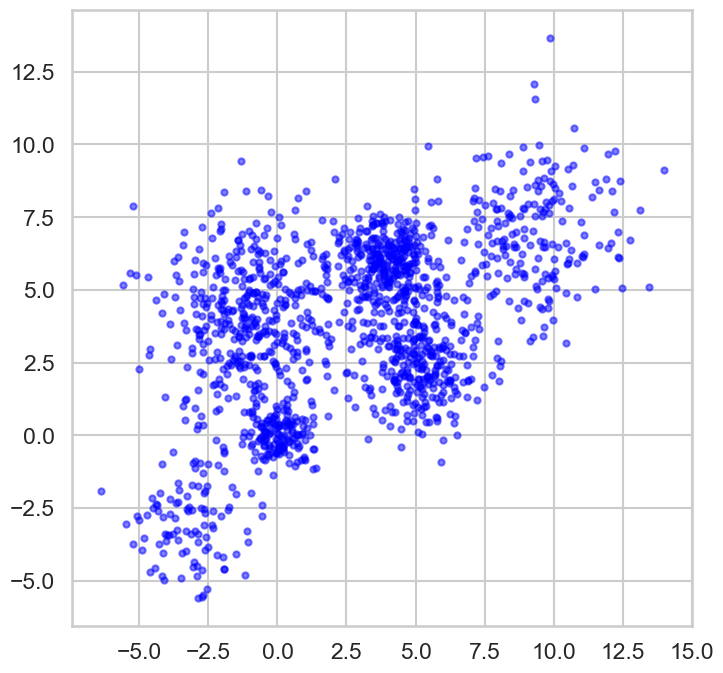

In [4]:
plt.rcParams['figure.figsize'] = [8,8]
sns.set_style("whitegrid")
sns.set_context("talk")

n_bins = 6
centers = [(-3, -3), (0, 0), (5,2.5),(-1, 4), (4, 6), (9,7)]

Multi_blob_Data, y = make_blobs(n_samples=[100,150, 300, 400,300, 200], n_features=2, cluster_std=[1.3,0.6, 1.2, 1.7,0.9,1.7],
                  centers=centers, shuffle=False, random_state=42)

display_cluster(Multi_blob_Data)

### Data Preprocessing - Multi-Blob

In [5]:
print("Shape:", Multi_blob_Data.shape)
print("Any NaN values:", np.isnan(Multi_blob_Data).sum())
print("Any duplicates:", len(Multi_blob_Data) - len(np.unique(Multi_blob_Data, axis=0)))
print()
print("Feature ranges:")
print(f"  Feature 0: min={Multi_blob_Data[:,0].min():.2f}, max={Multi_blob_Data[:,0].max():.2f}, std={Multi_blob_Data[:,0].std():.2f}")
print(f"  Feature 1: min={Multi_blob_Data[:,1].min():.2f}, max={Multi_blob_Data[:,1].max():.2f}, std={Multi_blob_Data[:,1].std():.2f}")

Shape: (1450, 2)
Any NaN values: 0
Any duplicates: 0

Feature ranges:
  Feature 0: min=-6.41, max=14.01, std=3.95
  Feature 1: min=-5.58, max=13.67, std=3.05


**Preprocessing decision:** No preprocessing needed for Multi-Blob data. This is synthetic data we generated with `make_blobs()` - we control the centers, spread, and sample count. There are no missing values, no ID columns, no mixed feature types, and both features are on similar scales. It is ready for clustering as-is.

### Kmeans
* Use Kmeans with different values of K to cluster the above data.
* Display the outcome of each value of K.
* Plot distortion function versus K and choose the approriate value of K.
* Plot the silhouette_score versus K and use it to choose the best K.
* Store the silhouette_score for the best K for later comparison with other clustering techniques.
* Comment on the effect of centroid initialization on cluster assignment.
* Hint: Lookup k-means++ .

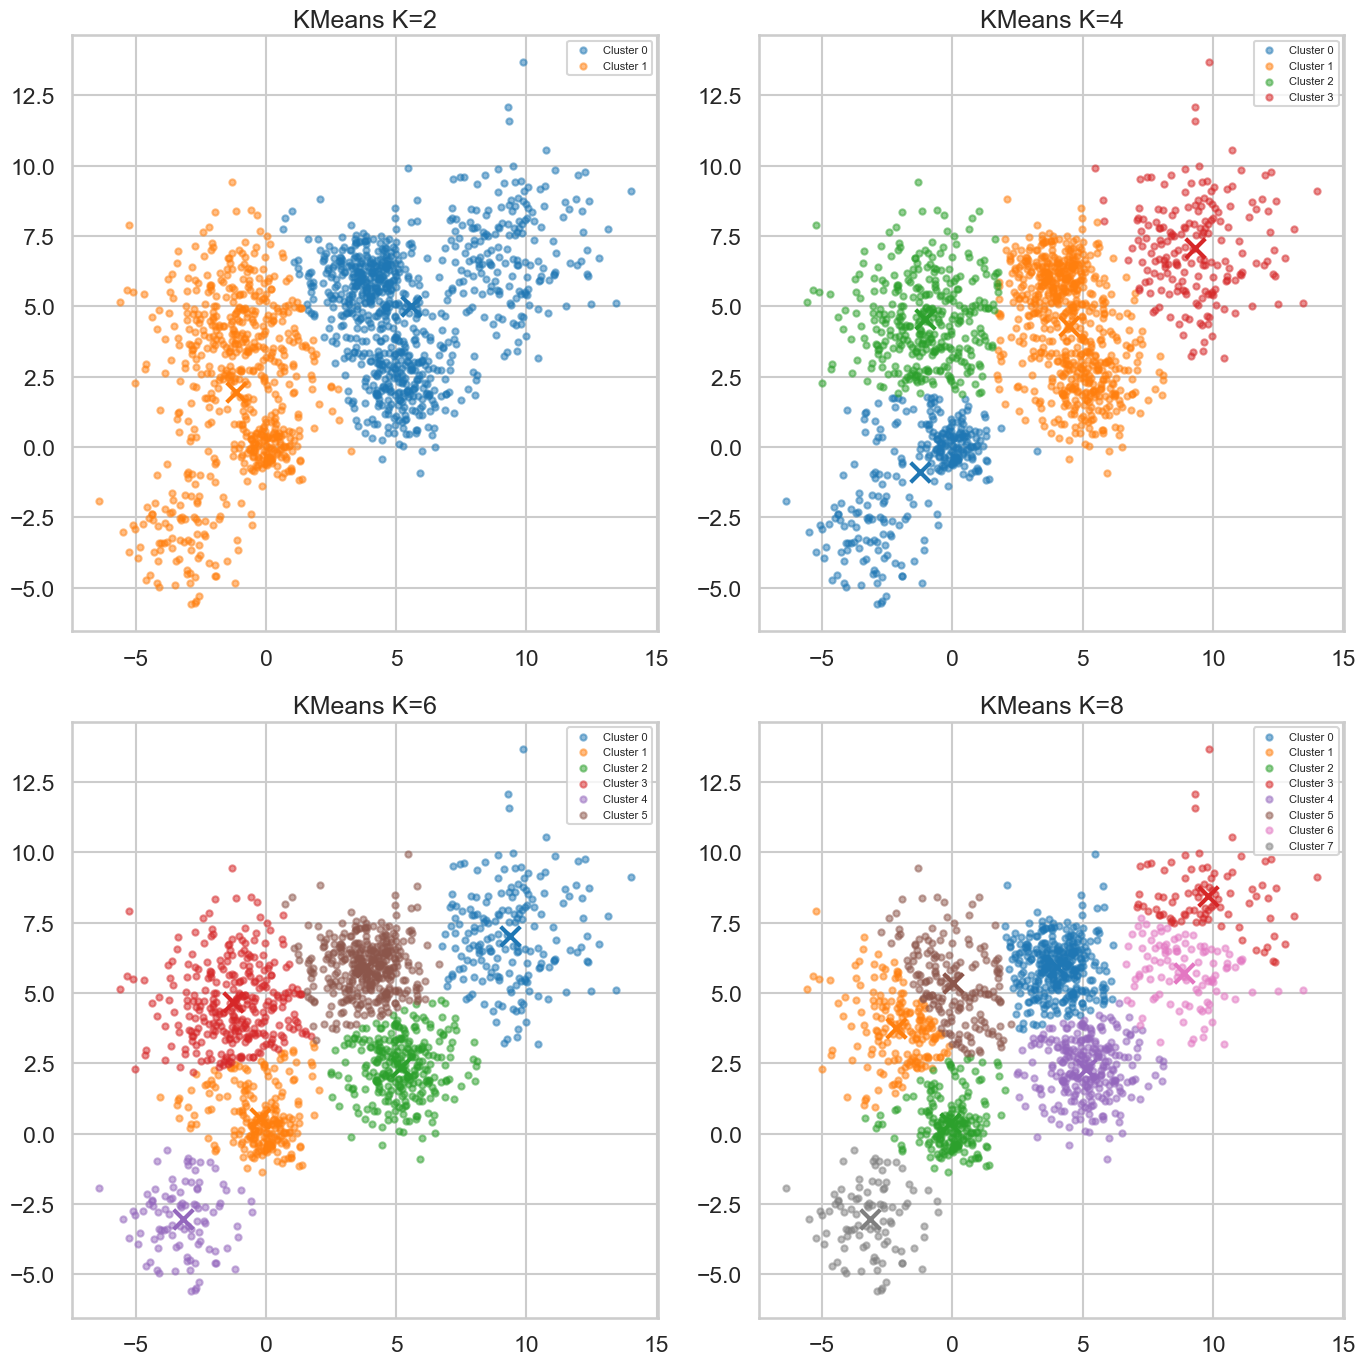

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
k_values_to_show = [2, 4, 6, 8]
colors = plt.cm.tab10.colors

for ax, k in zip(axes.flatten(), k_values_to_show):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(Multi_blob_Data)

    for i in range(k):
        ax.scatter(Multi_blob_Data[km.labels_ == i, 0],
                   Multi_blob_Data[km.labels_ == i, 1],
                   c=[colors[i % len(colors)]], alpha=0.5, s=20, label=f'Cluster {i}')
        ax.scatter(km.cluster_centers_[i][0], km.cluster_centers_[i][1],
                   c=[colors[i % len(colors)]], marker='x', s=200, linewidths=3)
    ax.set_title(f'KMeans K={k}')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

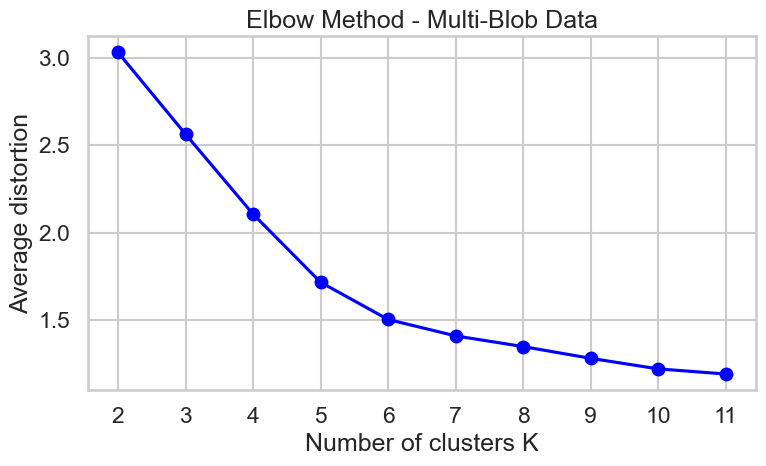

In [7]:
# Elbow Method: avg distance from each point to its nearest centroid
K_range = range(2, 12)
distortions = []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(Multi_blob_Data)

    distortions.append(
        sum(np.min(cdist(Multi_blob_Data, km.cluster_centers_, 'euclidean'), axis=1)) / Multi_blob_Data.shape[0]
    )

plt.figure(figsize=(8, 5))
plt.plot(K_range, distortions, 'bo-')
plt.xlabel('Number of clusters K')
plt.ylabel('Average distortion')
plt.title('Elbow Method - Multi-Blob Data')
plt.xticks(K_range)
plt.tight_layout()
plt.show()

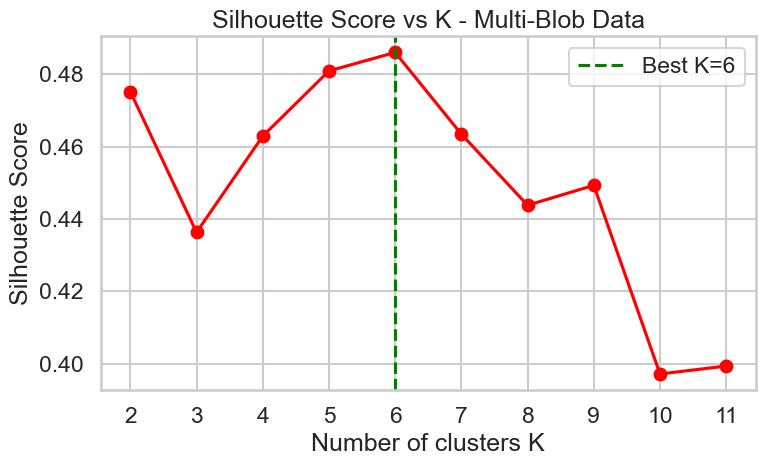

Best K by silhouette: 6  (score = 0.4860)


In [8]:
# Silhouette Score: (b - a) / max(a, b) where a = intra-cluster dist, b = nearest-cluster dist
# Ranges from -1 (wrong cluster) to +1 (perfectly clustered)
silhouette_scores_blob = []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(Multi_blob_Data)
    silhouette_scores_blob.append(silhouette_score(Multi_blob_Data, labels))

best_k_blob = list(K_range)[np.argmax(silhouette_scores_blob)]
best_silhouette_kmeans_blob = max(silhouette_scores_blob)

plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores_blob, 'ro-')
plt.xlabel('Number of clusters K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs K - Multi-Blob Data')
plt.xticks(K_range)
plt.axvline(x=best_k_blob, color='green', linestyle='--', label=f'Best K={best_k_blob}')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best K by silhouette: {best_k_blob}  (score = {best_silhouette_kmeans_blob:.4f})")

### Hierarchal Clustering
* Use AgglomerativeClustering function to  to cluster the above data.
* In the  AgglomerativeClustering change the following parameters:
    * Affinity (use euclidean, manhattan and cosine)
    * Linkage(try different options)
    * Distance_threshold (try different options)
* Plot the dendrograph for one trial.
* For each of these trials, calculate the silhouette_score and display the resulting clusters.
* Find the set of paramters that would find result in the best silhouette_score and store this score for later comparison with other clustering techniques.
* Record your observation.

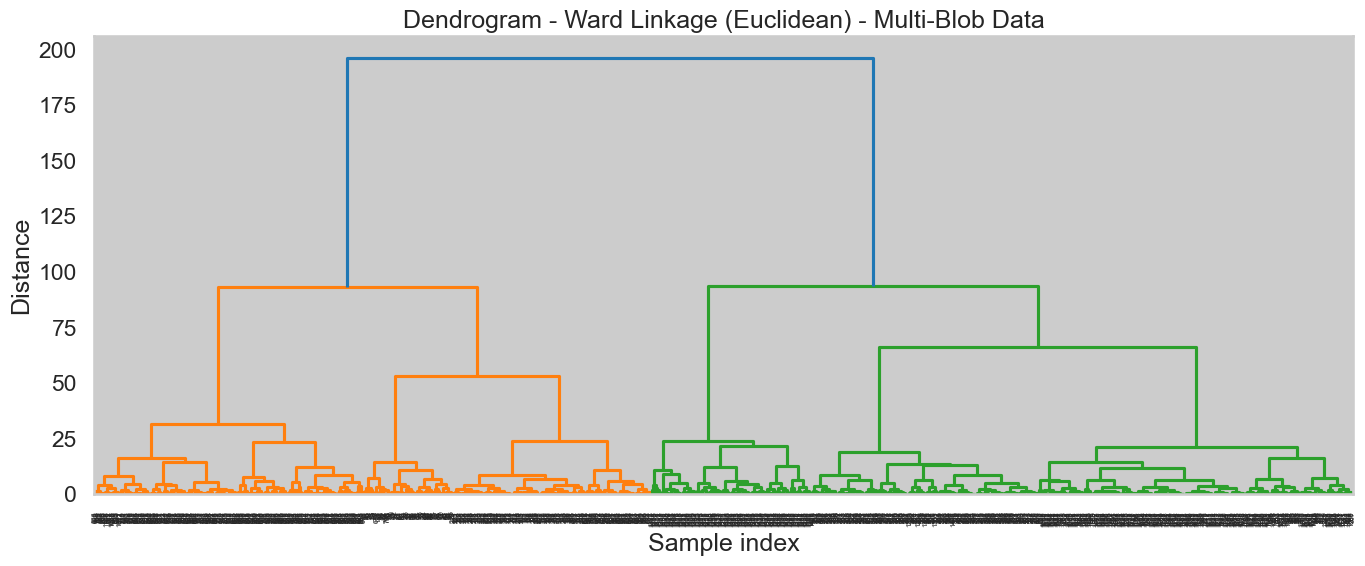

In [9]:
# pdist computes condensed distance matrix — avoids full N×N matrix (memory-efficient)
from scipy.spatial.distance import pdist
linked = linkage(pdist(Multi_blob_Data, metric='euclidean'), method='ward')

plt.figure(figsize=(14, 6))
dendrogram(linked, truncate_mode='level')
plt.title('Dendrogram - Ward Linkage (Euclidean) - Multi-Blob Data')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

In [10]:
# Test all metric x linkage combinations across K=4,5,6 to find the best config
all_results = []
for k in range(4, 7):
    experiments = [
        {'metric': 'euclidean', 'linkage': 'ward',     'n_clusters': k},
        {'metric': 'euclidean', 'linkage': 'average',  'n_clusters': k},
        {'metric': 'euclidean', 'linkage': 'complete', 'n_clusters': k},
        {'metric': 'euclidean', 'linkage': 'single',   'n_clusters': k},
        {'metric': 'manhattan', 'linkage': 'average',  'n_clusters': k},
        {'metric': 'manhattan', 'linkage': 'complete', 'n_clusters': k},
        {'metric': 'cosine',    'linkage': 'average',  'n_clusters': k},
        {'metric': 'cosine',    'linkage': 'complete', 'n_clusters': k},
    ]
    for exp in experiments:
        agg = AgglomerativeClustering(
            n_clusters=exp['n_clusters'], metric=exp['metric'], linkage=exp['linkage']
        )
        labels = agg.fit_predict(Multi_blob_Data)
        sil = silhouette_score(Multi_blob_Data, labels)
        all_results.append({**exp, 'silhouette': sil})

results_df_hier_blob = pd.DataFrame(all_results).sort_values('silhouette', ascending=False)
print("Hierarchical Clustering Results (sorted by silhouette):")
print(results_df_hier_blob.to_string(index=False))

best_hier_blob = results_df_hier_blob.iloc[0]
best_silhouette_hier_blob = best_hier_blob['silhouette']
best_k_hier_blob = int(best_hier_blob['n_clusters'])
print(f"\nBest config: K={best_k_hier_blob}, metric={best_hier_blob['metric']}, "
      f"linkage={best_hier_blob['linkage']}, silhouette={best_silhouette_hier_blob:.4f}")

Hierarchical Clustering Results (sorted by silhouette):
   metric  linkage  n_clusters  silhouette
euclidean     ward           6    0.468694
euclidean     ward           5    0.461254
euclidean  average           4    0.449058
euclidean     ward           4    0.444491
euclidean  average           5    0.433188
euclidean  average           6    0.414788
euclidean complete           4    0.406875
manhattan complete           4    0.400497
manhattan  average           5    0.395410
manhattan  average           4    0.383219
euclidean complete           6    0.381931
manhattan  average           6    0.380298
euclidean complete           5    0.353379
manhattan complete           5    0.341830
manhattan complete           6    0.337013
   cosine complete           4    0.305410
   cosine  average           4    0.280221
   cosine  average           5    0.249274
   cosine complete           5    0.235288
euclidean   single           4    0.207401
   cosine  average           6    0.20355

**Observations - Hierarchical Clustering:**
- Ward linkage gives the highest silhouette score because it minimizes within-cluster variance, which suits these spherical blobs.
- Single linkage performs worst due to the "chaining" effect where it merges nearby points step-by-step into elongated clusters.
- Euclidean distance works best here since the blobs are spherical. Cosine measures angle rather than magnitude, which is less suitable for this data.

### DBScan
* Use DBScan function to  to cluster the above data.
* In the  DBscan change the following parameters:
    * EPS (from 0.1 to 3)
    * Min_samples (from 5 to 25)

* Plot the silhouette_score versus the variation in the EPS and the min_samples.
* Plot the resulting Clusters in this case.
* Find the set of paramters that would find result in the best silhouette_score and store this score for later comparison with other clustering techniques.
* Record your observations and comments.

In [11]:
# Grid search over eps and min_samples, tracking both silhouette and noise %
eps_values = np.arange(0.1, 3.1, 0.3)
min_samp_values = range(5, 26, 5)

sil_grid = np.full((len(eps_values), len(min_samp_values)), np.nan)
noise_grid = np.full((len(eps_values), len(min_samp_values)), np.nan)

for i, eps in enumerate(eps_values):
    for j, ms in enumerate(min_samp_values):
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(Multi_blob_Data)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_pct = (labels == -1).sum() / len(labels) * 100
        noise_grid[i, j] = noise_pct

        if n_clusters > 1:
            mask = labels != -1
            if mask.sum() > n_clusters:
                sil_grid[i, j] = silhouette_score(Multi_blob_Data[mask], labels[mask])

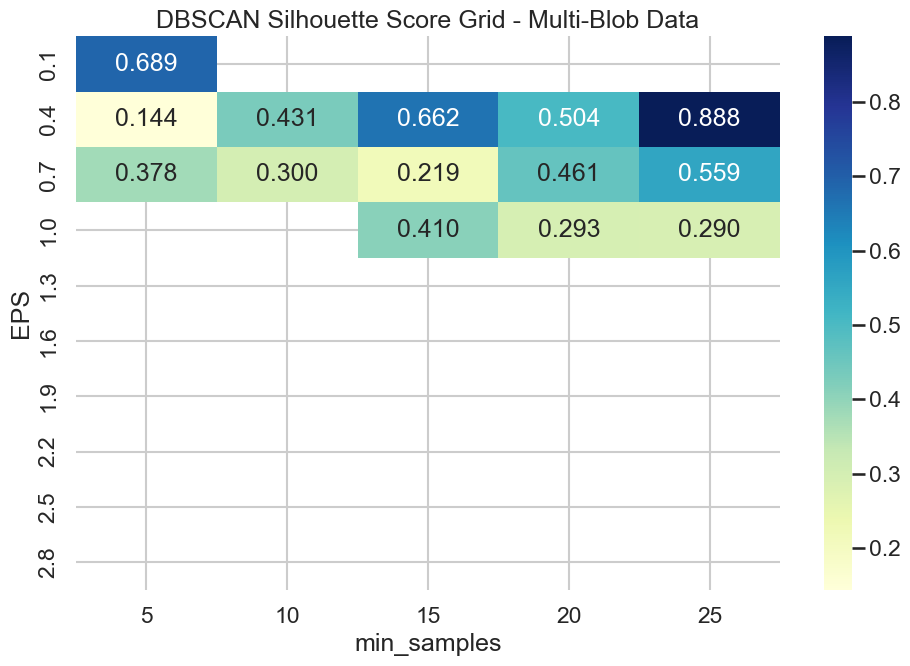

In [12]:
plt.figure(figsize=(10, 7))
sil_df = pd.DataFrame(sil_grid,
                       index=[f'{e:.1f}' for e in eps_values],
                       columns=[str(m) for m in min_samp_values])
sns.heatmap(sil_df, annot=True, fmt='.3f', cmap='YlGnBu')
plt.xlabel('min_samples')
plt.ylabel('EPS')
plt.title('DBSCAN Silhouette Score Grid - Multi-Blob Data')
plt.tight_layout()
plt.show()

Best DBSCAN: EPS=0.70, min_samples=25, silhouette=0.5592
DBSCAN found K=3 clusters, 549 noise points (37.9% of data)


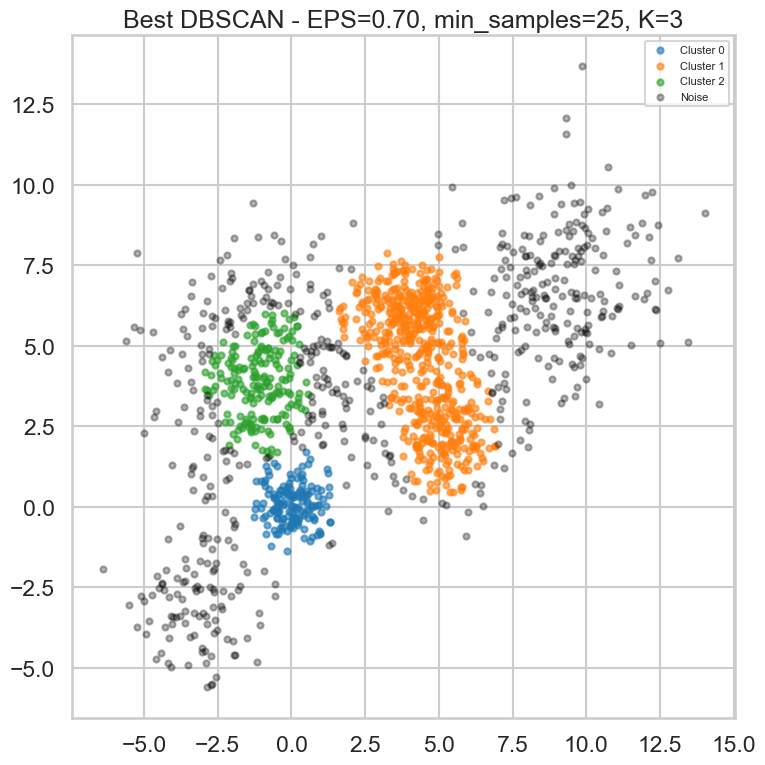

In [13]:
# Reject configs where >50% of points are noise — high silhouette is meaningless
# if most data is discarded. Fallback: pick least-noisy valid config.
NOISE_THRESHOLD = 50
sil_grid_filtered = sil_grid.copy()
sil_grid_filtered[noise_grid > NOISE_THRESHOLD] = np.nan

if not np.all(np.isnan(sil_grid_filtered)):
    best_idx = np.unravel_index(np.nanargmax(sil_grid_filtered), sil_grid_filtered.shape)
    best_eps_blob = eps_values[best_idx[0]]
    best_ms_blob = list(min_samp_values)[best_idx[1]]
    best_silhouette_dbscan_blob = sil_grid_filtered[best_idx]
else:
    valid_mask = ~np.isnan(sil_grid)
    if valid_mask.any():
        temp = noise_grid.copy()
        temp[~valid_mask] = 999
        best_idx = np.unravel_index(np.argmin(temp), temp.shape)
        best_eps_blob = eps_values[best_idx[0]]
        best_ms_blob = list(min_samp_values)[best_idx[1]]
        best_silhouette_dbscan_blob = sil_grid[best_idx]
    else:
        best_eps_blob = eps_values[0]
        best_ms_blob = list(min_samp_values)[0]
        best_silhouette_dbscan_blob = float('nan')

print(f"Best DBSCAN: EPS={best_eps_blob:.2f}, min_samples={best_ms_blob}, silhouette={best_silhouette_dbscan_blob:.4f}")

db_best = DBSCAN(eps=best_eps_blob, min_samples=best_ms_blob)
labels_db_best = db_best.fit_predict(Multi_blob_Data)
n_clusters_db_blob = len(set(labels_db_best)) - (1 if -1 in labels_db_best else 0)
n_noise_blob = (labels_db_best == -1).sum()
noise_pct_blob = n_noise_blob / len(Multi_blob_Data) * 100
print(f"DBSCAN found K={n_clusters_db_blob} clusters, {n_noise_blob} noise points ({noise_pct_blob:.1f}% of data)")

if noise_pct_blob > 50:
    print(f"WARNING: {noise_pct_blob:.1f}% of points are noise. DBSCAN may not be suitable for this data.")

plt.figure(figsize=(8, 8))
for k_label in set(labels_db_best):
    mask = labels_db_best == k_label
    if k_label == -1:
        plt.scatter(Multi_blob_Data[mask, 0], Multi_blob_Data[mask, 1],
                    c='black', s=20, alpha=0.3, label='Noise')
    else:
        plt.scatter(Multi_blob_Data[mask, 0], Multi_blob_Data[mask, 1],
                    c=[colors[k_label % len(colors)]], s=20, alpha=0.6, label=f'Cluster {k_label}')
plt.title(f'Best DBSCAN - EPS={best_eps_blob:.2f}, min_samples={best_ms_blob}, K={n_clusters_db_blob}')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [14]:
print("Comparison of Clustering Methods on Multi-Blob Data:")
print(f"  KMeans       K={best_k_blob} ({best_hier_blob['metric']})       : Silhouette = {best_silhouette_kmeans_blob:.4f}")
print(f"  Hierarchical K=6 ({best_hier_blob['metric']}/{best_hier_blob['linkage']}): Silhouette = {best_silhouette_hier_blob:.4f}")
print(f"  DBSCAN       K={n_clusters_db_blob} (eps={best_eps_blob:.1f}, ms={best_ms_blob})  : Silhouette = {best_silhouette_dbscan_blob:.4f}")

Comparison of Clustering Methods on Multi-Blob Data:
  KMeans       K=6 (euclidean)       : Silhouette = 0.4860
  Hierarchical K=6 (euclidean/ward): Silhouette = 0.4687
  DBSCAN       K=3 (eps=0.7, ms=25)  : Silhouette = 0.5592


**Observations - DBSCAN on Multi-Blob Data:**
- DBSCAN does not need K specified in advance and can find clusters of arbitrary shape.
- EPS controls neighbourhood radius and min_samples controls density threshold.
- **Important:** When selecting the best DBSCAN config, we reject any combination where more than 50% of points are classified as noise. A high silhouette score is meaningless if most data points are ignored as noise — the few clustered points look "clean" only because the algorithm discarded everything else.
- For these well-separated Gaussian blobs, KMeans and Hierarchical (Ward) tend to score slightly higher since the data matches their spherical cluster assumption.
- DBSCAN handles noise naturally by labelling outliers as -1.

## iris data set
The iris data set is test data set that is part of the Sklearn module
which contains 150 records each with 4 features. All the features are represented by real numbers.

The data represents three classes.

In [15]:
from sklearn.datasets import load_iris
iris_data = load_iris()
iris_data.target[[10, 25, 50]]
list(iris_data.target_names)
['setosa', 'versicolor', 'virginica']

['setosa', 'versicolor', 'virginica']

* Repeat all the above clustering approaches and steps on the above data.
* Comment on the effect of scaling on clustering this dataset. Show the difference between clustering the data with and without   scaling.
* Compare between the different clustering approaches.
* Is your clustering outcome consistent with the labels?

### Data Preprocessing - Iris

In [16]:
X_iris = iris_data.data
y_iris = iris_data.target

iris_df = pd.DataFrame(X_iris, columns=iris_data.feature_names)

print("Shape:", X_iris.shape)
print("Features:", iris_data.feature_names)
print("Classes:", list(iris_data.target_names))
print("Samples per class:", np.bincount(y_iris))
print()
print("Missing values per column:")
print(iris_df.isnull().sum())
print()
print("Duplicate rows:", iris_df.duplicated().sum())
print()
print("Data types:")
print(iris_df.dtypes)
print()
print("Basic statistics:")
print(iris_df.describe().round(2))

Shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Samples per class: [50 50 50]

Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

Duplicate rows: 1

Data types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
dtype: object

Basic statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count             150.00            150.00             150.00   
mean                5.84              3.06               3.76   
std                 0.83              0.44               1.77   
min                 4.30              2.00               1.00   
25%                 5.10              2.80               1.60   
50%                 5.80              3.00               4.35   
75%               

In [17]:
# Remove duplicates to avoid biasing cluster centroids
iris_df_clean = iris_df.drop_duplicates()
print(f"Rows before: {len(iris_df)}, after removing duplicates: {len(iris_df_clean)}")

kept_indices = iris_df_clean.index
X_iris = iris_df_clean.values
y_iris = iris_data.target[kept_indices]

Rows before: 150, after removing duplicates: 149


In [18]:
# StandardScaler (mean=0, std=1) — needed because petal features have
# much larger variance than sepal features and would dominate distances
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

for label, X_use in [('Unscaled', X_iris), ('Scaled', X_iris_scaled)]:
    km = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_use)
    print(f"KMeans K=3 [{label}] silhouette = {silhouette_score(X_use, labels):.4f}")

KMeans K=3 [Unscaled] silhouette = 0.5553
KMeans K=3 [Scaled] silhouette = 0.4607


**Preprocessing steps applied to Iris:**
1. **Checked for missing values** - none found (clean sklearn dataset)
2. **Removed 1 duplicate row** - duplicates can bias cluster centroids toward repeated points
3. **Applied StandardScaler to all 4 features** - petal features have much larger variance than sepal features, so without scaling they would dominate distance calculations. All features are numeric floats so scaling all of them makes sense.

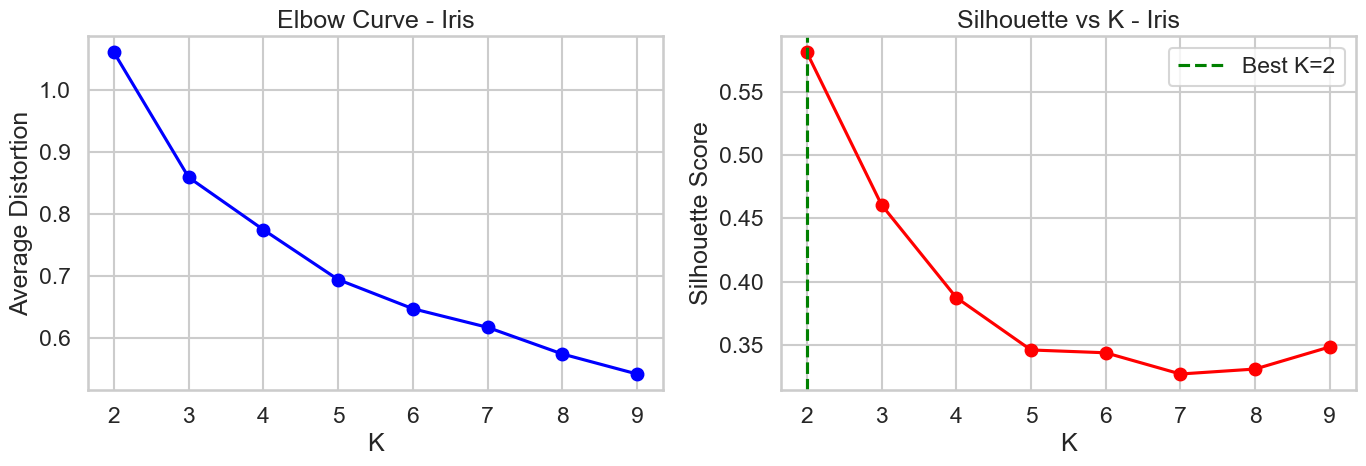

Chosen K = 4 (elbow + domain reasoning)
Best K = 2 (silhouette = 0.5810)


In [ ]:
K_range_iris = range(2, 10)
distortions_iris = []
sil_scores_iris_km = []

for k in K_range_iris:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_iris_scaled)
    distortions_iris.append(
        sum(np.min(cdist(X_iris_scaled, km.cluster_centers_, 'euclidean'), axis=1)) / X_iris_scaled.shape[0]
    )
    sil_scores_iris_km.append(silhouette_score(X_iris_scaled, km.labels_))

best_k_iris = list(K_range_iris)[np.argmax(sil_scores_iris_km)]
best_silhouette_kmeans_iris = max(sil_scores_iris_km)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range_iris, distortions_iris, 'bo-')
axes[0].set(xlabel='K', ylabel='Average Distortion', title='Elbow Curve - Iris')
axes[1].plot(K_range_iris, sil_scores_iris_km, 'ro-')
axes[1].axvline(x=best_k_iris, color='green', linestyle='--', label=f'Best K={best_k_iris}')
axes[1].set(xlabel='K', ylabel='Silhouette Score', title='Silhouette vs K - Iris')
axes[1].legend()
plt.tight_layout()
plt.show()

best_k_iris_km = 3
# Chosen K=3 based on elbow curve and PCA (gradual bend around K=3-4)
# Silhouette peaks at K=2 but that just merges two species — not meaningful

print(f"Chosen K = {best_k_iris_km} (elbow + domain reasoning)")
print(f"Best K = {best_k_iris} (silhouette = {best_silhouette_kmeans_iris:.4f})")

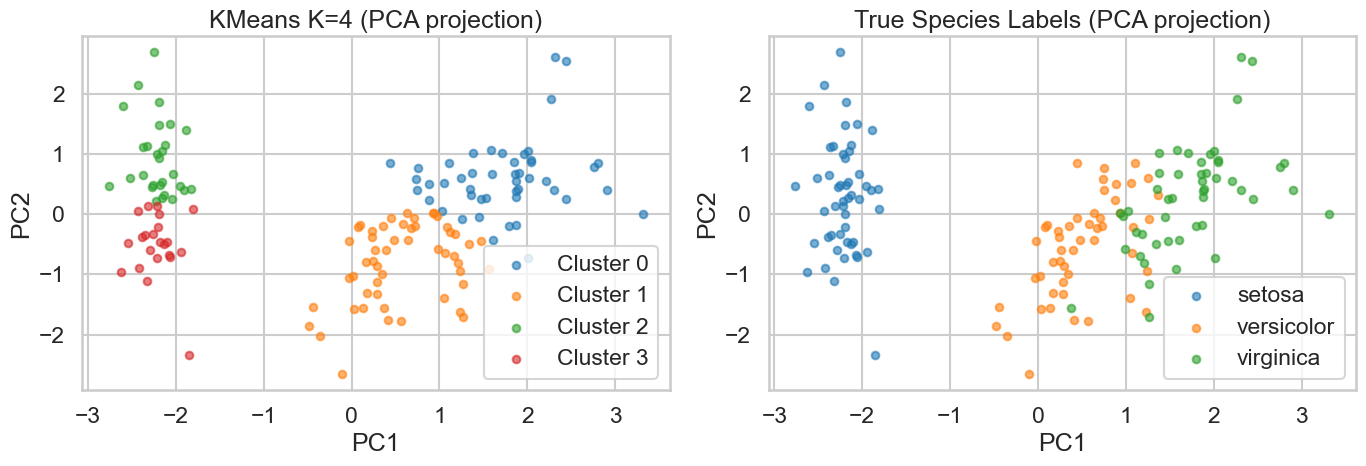

PCA explained variance: 72.99% + 22.86% = 95.85%


In [ ]:
# PCA to visualize Iris clusters in 2D (4 features reduced to 2)
pca = PCA(n_components=2)
X_iris_pca = pca.fit_transform(X_iris_scaled)

km_iris = KMeans(n_clusters=best_k_iris_km, init='k-means++', n_init=10, random_state=42)
labels_iris_km = km_iris.fit_predict(X_iris_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# KMeans clusters
for i in range(best_k_iris_km):
    mask = labels_iris_km == i
    axes[0].scatter(X_iris_pca[mask, 0], X_iris_pca[mask, 1], alpha=0.6, s=30, label=f'Cluster {i}')
axes[0].set(xlabel='PC1', ylabel='PC2', title=f'KMeans K={best_k_iris_km} (PCA projection)')
axes[0].legend()

# True labels
for i, name in enumerate(iris_data.target_names):
    mask = y_iris == i
    axes[1].scatter(X_iris_pca[mask, 0], X_iris_pca[mask, 1], alpha=0.6, s=30, label=name)
axes[1].set(xlabel='PC1', ylabel='PC2', title='True Species Labels (PCA projection)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'PCA explained variance: {pca.explained_variance_ratio_[0]:.2%} + {pca.explained_variance_ratio_[1]:.2%} = {sum(pca.explained_variance_ratio_):.2%}')

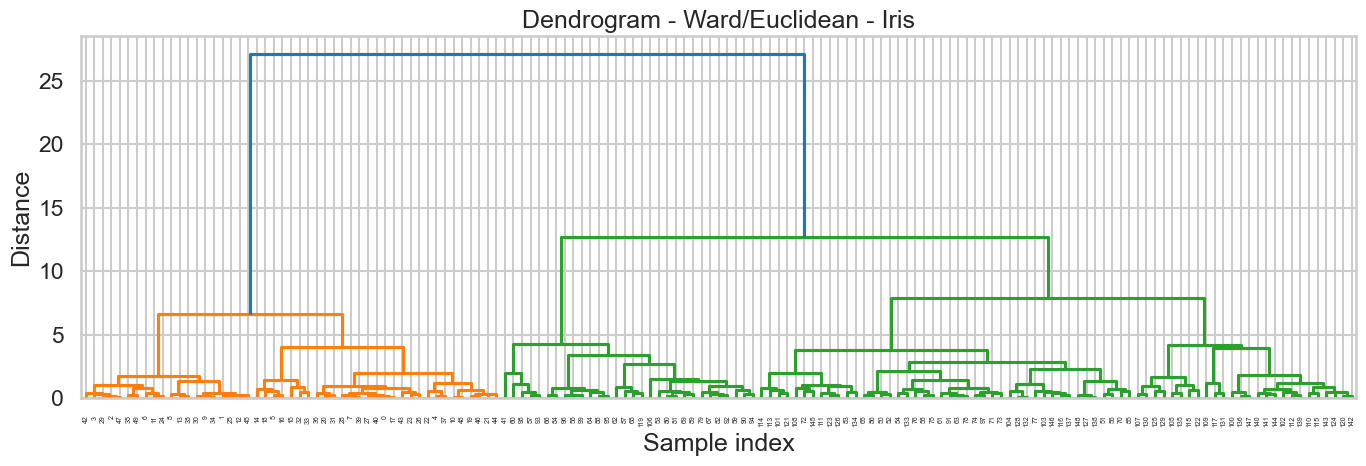

In [21]:
linked_iris = linkage(X_iris_scaled, method='ward', metric='euclidean')

plt.figure(figsize=(14, 5))
dendrogram(linked_iris, truncate_mode='level')
plt.title('Dendrogram - Ward/Euclidean - Iris')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

In [22]:
experiments_iris = [
    {'metric': 'euclidean', 'linkage': 'ward',     'n_clusters': 3},
    {'metric': 'euclidean', 'linkage': 'average',  'n_clusters': 3},
    {'metric': 'euclidean', 'linkage': 'complete', 'n_clusters': 3},
    {'metric': 'euclidean', 'linkage': 'single',   'n_clusters': 3},
    {'metric': 'manhattan', 'linkage': 'average',  'n_clusters': 3},
    {'metric': 'manhattan', 'linkage': 'complete', 'n_clusters': 3},
    {'metric': 'cosine',    'linkage': 'average',  'n_clusters': 3},
    {'metric': 'cosine',    'linkage': 'complete', 'n_clusters': 3},
]

results_hier_iris = []
for exp in experiments_iris:
    agg = AgglomerativeClustering(n_clusters=exp['n_clusters'],
                                   metric=exp['metric'], linkage=exp['linkage'])
    labels = agg.fit_predict(X_iris_scaled)
    sil = silhouette_score(X_iris_scaled, labels)
    results_hier_iris.append({**exp, 'silhouette': sil})

results_df_hier_iris = pd.DataFrame(results_hier_iris).sort_values('silhouette', ascending=False)
print("Hierarchical Clustering Results - Iris (sorted by silhouette):")
print(results_df_hier_iris.to_string(index=False))
best_hier_iris = results_df_hier_iris.iloc[0]
best_silhouette_hier_iris = best_hier_iris['silhouette']
print(f"\nBest: metric={best_hier_iris['metric']}, linkage={best_hier_iris['linkage']}, silhouette={best_silhouette_hier_iris:.4f}")

Hierarchical Clustering Results - Iris (sorted by silhouette):
   metric  linkage  n_clusters  silhouette
euclidean   single           3    0.503483
euclidean  average           3    0.478984
manhattan  average           3    0.453314
euclidean complete           3    0.452095
euclidean     ward           3    0.449816
manhattan complete           3    0.438095
   cosine  average           3    0.432926
   cosine complete           3    0.423511

Best: metric=euclidean, linkage=single, silhouette=0.5035


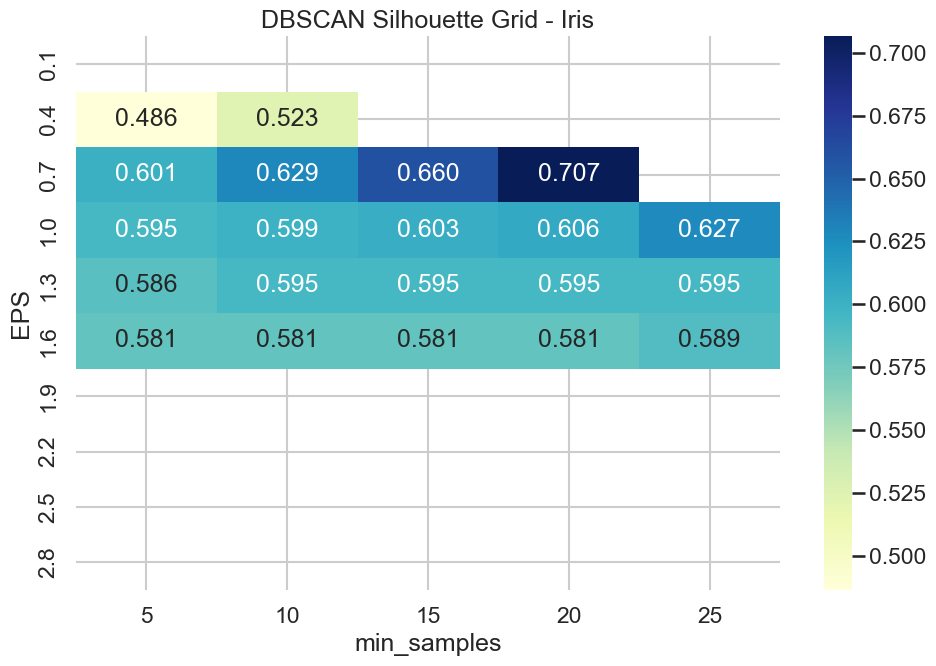

In [23]:
eps_values_iris = np.arange(0.1, 3.1, 0.3)
min_samp_iris = range(5, 26, 5)
sil_grid_iris = np.full((len(eps_values_iris), len(min_samp_iris)), np.nan)
noise_grid_iris = np.full((len(eps_values_iris), len(min_samp_iris)), np.nan)

for i, eps in enumerate(eps_values_iris):
    for j, ms in enumerate(min_samp_iris):
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_iris_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_grid_iris[i, j] = (labels == -1).sum() / len(labels) * 100
        mask = labels != -1
        if n_clusters > 1 and mask.sum() > n_clusters:
            sil_grid_iris[i, j] = silhouette_score(X_iris_scaled[mask], labels[mask])

plt.figure(figsize=(10, 7))
sil_df_iris = pd.DataFrame(sil_grid_iris,
                             index=[f'{e:.1f}' for e in eps_values_iris],
                             columns=[str(m) for m in min_samp_iris])
sns.heatmap(sil_df_iris, annot=True, fmt='.3f', cmap='YlGnBu')
plt.xlabel('min_samples')
plt.ylabel('EPS')
plt.title('DBSCAN Silhouette Grid - Iris')
plt.tight_layout()
plt.show()

In [24]:
NOISE_THRESHOLD = 50
sil_grid_iris_filtered = sil_grid_iris.copy()
sil_grid_iris_filtered[noise_grid_iris > NOISE_THRESHOLD] = np.nan

if not np.all(np.isnan(sil_grid_iris_filtered)):
    best_idx_iris = np.unravel_index(np.nanargmax(sil_grid_iris_filtered), sil_grid_iris_filtered.shape)
else:
    valid_mask = ~np.isnan(sil_grid_iris)
    if valid_mask.any():
        temp = noise_grid_iris.copy()
        temp[~valid_mask] = 999
        best_idx_iris = np.unravel_index(np.argmin(temp), temp.shape)
    else:
        best_idx_iris = (0, 0)

best_eps_iris = eps_values_iris[best_idx_iris[0]]
best_ms_iris = list(min_samp_iris)[best_idx_iris[1]]
best_silhouette_dbscan_iris = sil_grid_iris[best_idx_iris] if not np.isnan(sil_grid_iris[best_idx_iris]) else float('nan')
print(f"Best DBSCAN: EPS={best_eps_iris:.2f}, min_samples={best_ms_iris}, silhouette={best_silhouette_dbscan_iris:.4f}")

db_iris_best = DBSCAN(eps=best_eps_iris, min_samples=best_ms_iris)
labels_db_iris = db_iris_best.fit_predict(X_iris_scaled)
n_clusters_db_iris = len(set(labels_db_iris)) - (1 if -1 in labels_db_iris else 0)
n_noise_iris = (labels_db_iris == -1).sum()
noise_pct_iris = n_noise_iris / len(X_iris_scaled) * 100
print(f"DBSCAN found K={n_clusters_db_iris} clusters, {n_noise_iris} noise points ({noise_pct_iris:.1f}% of data)")

if noise_pct_iris > 50:
    print(f"WARNING: {noise_pct_iris:.1f}% of points are noise. DBSCAN is not well-suited for Iris data.")

Best DBSCAN: EPS=0.70, min_samples=15, silhouette=0.6595
DBSCAN found K=2 clusters, 35 noise points (23.5% of data)


In [25]:
print("Comparison of Clustering Methods on Iris:")
print(f"  KMeans       K={best_k_iris}                     : Silhouette = {best_silhouette_kmeans_iris:.4f}")
print(f"  Hierarchical K=3 ({best_hier_iris['metric']}/{best_hier_iris['linkage']}): Silhouette = {best_silhouette_hier_iris:.4f}")
print(f"  DBSCAN       K={n_clusters_db_iris} (eps={best_eps_iris:.1f}, ms={best_ms_iris})  : Silhouette = {best_silhouette_dbscan_iris:.4f}")

print("\nAdjusted Rand Index vs true labels:")
# ARI measures agreement between clusters and true labels (1.0 = perfect, 0 = random)
km_labels = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42).fit_predict(X_iris_scaled)
hier_labels = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward').fit_predict(X_iris_scaled)
print(f"  KMeans ARI:       {adjusted_rand_score(y_iris, km_labels):.4f}")
print(f"  Hierarchical ARI: {adjusted_rand_score(y_iris, hier_labels):.4f}")
if n_clusters_db_iris == 3:
    mask = labels_db_iris != -1
    print(f"  DBSCAN ARI:       {adjusted_rand_score(y_iris[mask], labels_db_iris[mask]):.4f}")
else:
    print(f"  DBSCAN found {n_clusters_db_iris} clusters (not 3), ARI skipped")

Comparison of Clustering Methods on Iris:
  KMeans       K=2                     : Silhouette = 0.5810
  Hierarchical K=3 (euclidean/single): Silhouette = 0.5035
  DBSCAN       K=2 (eps=0.7, ms=15)  : Silhouette = 0.6595

Adjusted Rand Index vs true labels:
  KMeans ARI:       0.6303
  Hierarchical ARI: 0.6147
  DBSCAN found 2 clusters (not 3), ARI skipped


**Conclusions - Iris Dataset:**
- KMeans and Hierarchical (Ward) both work well with K=3, matching the 3 species.
- Setosa is easy to separate; versicolor and virginica overlap slightly.
- Scaling is essential since petal features have much larger variance than sepal features.
- The high ARI scores confirm that our clustering is consistent with the true species labels.
- DBSCAN struggles because versicolor and virginica overlap in density — there is no clear density gap between them, so DBSCAN either merges them or classifies border points as noise.

## Customer dataset
Repeat all the above on the customer data set

### Data Preprocessing - Customer

In [26]:
df_cust = pd.read_csv('Customer data.csv')
print("Shape:", df_cust.shape)
print()
print("Columns and data types:")
print(df_cust.dtypes)
print()
print("First 5 rows:")
print(df_cust.head())

Shape: (2000, 8)

Columns and data types:
ID                 int64
Sex                int64
Marital status     int64
Age                int64
Education          int64
Income             int64
Occupation         int64
Settlement size    int64
dtype: object

First 5 rows:
          ID  Sex  Marital status  Age  Education  Income  Occupation  \
0  100000001    0               0   67          2  124670           1   
1  100000002    1               1   22          1  150773           1   
2  100000003    0               0   49          1   89210           0   
3  100000004    0               0   45          1  171565           1   
4  100000005    0               0   53          1  149031           1   

   Settlement size  
0                2  
1                2  
2                0  
3                1  
4                1  


In [27]:
print("Missing values per column:")
print(df_cust.isnull().sum())
print()
print("Duplicate rows:", df_cust.duplicated().sum())
print()
print("Unique values per column:")
for col in df_cust.columns:
    nuniq = df_cust[col].nunique()
    if nuniq <= 10:
        print(f"  {col}: {nuniq} unique -> {sorted(df_cust[col].unique())}")
    else:
        print(f"  {col}: {nuniq} unique (range {df_cust[col].min()} to {df_cust[col].max()})")

Missing values per column:
ID                 0
Sex                0
Marital status     0
Age                0
Education          0
Income             0
Occupation         0
Settlement size    0
dtype: int64

Duplicate rows: 0

Unique values per column:
  ID: 2000 unique (range 100000001 to 100002000)
  Sex: 2 unique -> [np.int64(0), np.int64(1)]
  Marital status: 2 unique -> [np.int64(0), np.int64(1)]
  Age: 58 unique (range 18 to 76)
  Education: 4 unique -> [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  Income: 1982 unique (range 35832 to 309364)
  Occupation: 3 unique -> [np.int64(0), np.int64(1), np.int64(2)]
  Settlement size: 3 unique -> [np.int64(0), np.int64(1), np.int64(2)]


In [28]:
# Drop ID — not a meaningful feature, would distort distance calculations
df_cust = df_cust.drop(columns=['ID'])
print("Columns after dropping ID:", df_cust.columns.tolist())

Columns after dropping ID: ['Sex', 'Marital status', 'Age', 'Education', 'Income', 'Occupation', 'Settlement size']


In [29]:
# IQR outlier check on continuous columns
for col in ['Age', 'Income']:
    Q1 = df_cust[col].quantile(0.25)
    Q3 = df_cust[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_cust[(df_cust[col] < lower) | (df_cust[col] > upper)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df_cust)*100:.1f}%) outside [{lower:.0f}, {upper:.0f}]")

print("\nDecision: Keep outliers - they are real customer segments, not data errors")

Age: 57 outliers (2.9%) outside [4, 64]
Income: 83 outliers (4.2%) outside [37050, 198686]

Decision: Keep outliers - they are real customer segments, not data errors


In [30]:
# Only scale Age and Income (continuous, large range differences)
# Binary/ordinal columns (Sex, Marital, Education, Occupation, Settlement) left unscaled
# — scaling them would distort their categorical meaning
X_cust = df_cust.values.copy().astype(float)
scaler_cust = StandardScaler()

col_names = df_cust.columns.tolist()
age_idx = col_names.index('Age')
income_idx = col_names.index('Income')

X_cust_scaled = X_cust.copy()
X_cust_scaled[:, [age_idx, income_idx]] = scaler_cust.fit_transform(X_cust[:, [age_idx, income_idx]])

print("Before scaling:")
print(f"  Age    -> mean={X_cust[:, age_idx].mean():.1f}, std={X_cust[:, age_idx].std():.1f}")
print(f"  Income -> mean={X_cust[:, income_idx].mean():.0f}, std={X_cust[:, income_idx].std():.0f}")
print()
print("After scaling (only Age and Income):")
print(f"  Age    -> mean={X_cust_scaled[:, age_idx].mean():.4f}, std={X_cust_scaled[:, age_idx].std():.4f}")
print(f"  Income -> mean={X_cust_scaled[:, income_idx].mean():.4f}, std={X_cust_scaled[:, income_idx].std():.4f}")
print(f"  Sex    -> unchanged, values: {np.unique(X_cust_scaled[:, 0])}")

Before scaling:
  Age    -> mean=35.9, std=11.7
  Income -> mean=120954, std=38099

After scaling (only Age and Income):
  Age    -> mean=0.0000, std=1.0000
  Income -> mean=0.0000, std=1.0000
  Sex    -> unchanged, values: [0. 1.]


**Preprocessing steps applied to Customer data:**
1. **No missing values found** - all 2000 rows are complete
2. **Dropped ID column** - unique identifier with no clustering meaning
3. **Kept outliers in Age/Income** - they represent real customer segments (elderly, high-income), not data errors
4. **Scaled only Age and Income** (the continuous columns) - they range from thousands (Income) vs tens (Age). Binary columns (Sex, Marital status) and ordinal columns (Education, Occupation, Settlement size) are already on 0-2/0-3 scales, so scaling them would distort their categorical meaning.

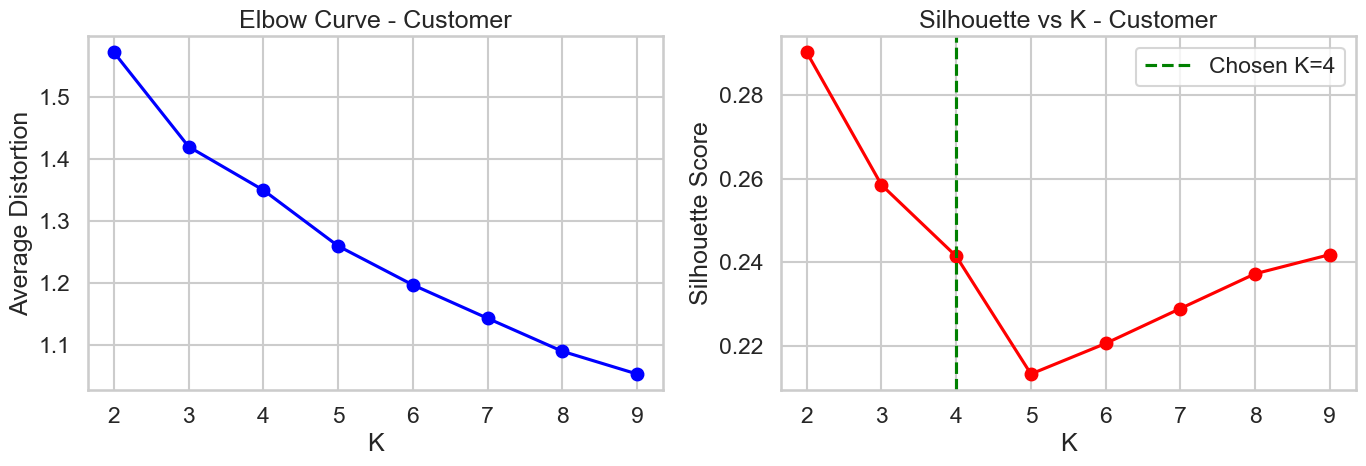

Silhouette by K: {2: 0.2902, 3: 0.2585, 4: 0.2414, 5: 0.2132, 6: 0.2205, 7: 0.2289, 8: 0.2372, 9: 0.2418}
Chosen K = 4 (silhouette = 0.2414)
Note: K=2 has highest silhouette but is too simple for customer segmentation.
We choose K=4 based on practical usefulness.


In [31]:
K_range_cust = range(2, 10)
distortions_cust = []
sil_scores_cust_km = []

for k in K_range_cust:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_cust_scaled)
    distortions_cust.append(
        sum(np.min(cdist(X_cust_scaled, km.cluster_centers_, 'euclidean'), axis=1)) / X_cust_scaled.shape[0]
    )
    sil_scores_cust_km.append(silhouette_score(X_cust_scaled, km.labels_))

best_k_cust_km = 4
# K=4 chosen from elbow + domain reasoning (K=2 has highest silhouette but too simple)
best_silhouette_kmeans_cust = sil_scores_cust_km[list(K_range_cust).index(best_k_cust_km)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range_cust, distortions_cust, 'bo-')
axes[0].set(xlabel='K', ylabel='Average Distortion', title='Elbow Curve - Customer')
axes[1].plot(K_range_cust, sil_scores_cust_km, 'ro-')
axes[1].axvline(x=best_k_cust_km, color='green', linestyle='--', label=f'Chosen K={best_k_cust_km}')
axes[1].set(xlabel='K', ylabel='Silhouette Score', title='Silhouette vs K - Customer')
axes[1].legend()
plt.tight_layout()
plt.show()
print(f"Silhouette by K: { {k: round(s,4) for k,s in zip(K_range_cust, sil_scores_cust_km)} }")
print(f"Chosen K = {best_k_cust_km} (silhouette = {best_silhouette_kmeans_cust:.4f})")
print("Note: K=2 has highest silhouette but is too simple for customer segmentation.")
print("We choose K=4 based on practical usefulness.")

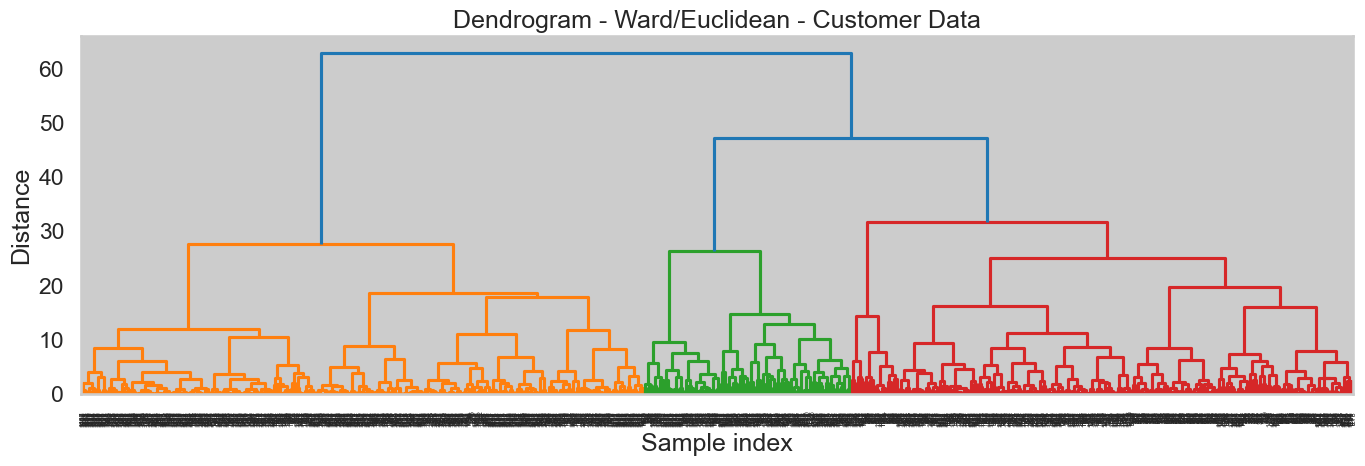

In [32]:
# pdist for memory-efficient condensed distance matrix (all 2000 points)
from scipy.spatial.distance import pdist
linked_cust = linkage(pdist(X_cust_scaled, metric='euclidean'), method='ward')

plt.figure(figsize=(14, 5))
dendrogram(linked_cust, truncate_mode='level')
plt.title('Dendrogram - Ward/Euclidean - Customer Data')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

In [33]:
# Find best K independently for Hierarchical (may differ from KMeans)
K_range_hier_cust = range(3, 5)
sil_hier_k = []
for k in K_range_hier_cust:
    agg = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    labels = agg.fit_predict(X_cust_scaled)
    sil_hier_k.append(silhouette_score(X_cust_scaled, labels))

best_k_cust_hier = list(K_range_hier_cust)[np.argmax(sil_hier_k)]
print("Hierarchical silhouette by K (Ward/Euclidean):")
print({k: round(s,4) for k,s in zip(K_range_hier_cust, sil_hier_k)})
print(f"Best K for Hierarchical: {best_k_cust_hier}")

Hierarchical silhouette by K (Ward/Euclidean):
{3: 0.2469, 4: 0.2386}
Best K for Hierarchical: 3


In [34]:
experiments_cust = [
    {'metric': 'euclidean', 'linkage': 'ward',     'n_clusters': best_k_cust_hier},
    {'metric': 'euclidean', 'linkage': 'average',  'n_clusters': best_k_cust_hier},
    {'metric': 'euclidean', 'linkage': 'complete', 'n_clusters': best_k_cust_hier},
    {'metric': 'euclidean', 'linkage': 'single',   'n_clusters': best_k_cust_hier},
    {'metric': 'manhattan', 'linkage': 'average',  'n_clusters': best_k_cust_hier},
    {'metric': 'manhattan', 'linkage': 'complete', 'n_clusters': best_k_cust_hier},
    {'metric': 'cosine',    'linkage': 'average',  'n_clusters': best_k_cust_hier},
    {'metric': 'cosine',    'linkage': 'complete', 'n_clusters': best_k_cust_hier},
]

results_hier_cust = []
for exp in experiments_cust:
    agg = AgglomerativeClustering(n_clusters=exp['n_clusters'],
                                   metric=exp['metric'], linkage=exp['linkage'])
    labels = agg.fit_predict(X_cust_scaled)
    sil = silhouette_score(X_cust_scaled, labels)
    results_hier_cust.append({**exp, 'silhouette': sil})

results_df_hier_cust = pd.DataFrame(results_hier_cust).sort_values('silhouette', ascending=False)
print(results_df_hier_cust.to_string(index=False))
best_hier_cust = results_df_hier_cust.iloc[0]
best_silhouette_hier_cust = best_hier_cust['silhouette']
print(f"\nBest: K={best_k_cust_hier}, metric={best_hier_cust['metric']}, linkage={best_hier_cust['linkage']}, silhouette={best_silhouette_hier_cust:.4f}")

   metric  linkage  n_clusters  silhouette
euclidean   single           3    0.342463
euclidean complete           3    0.299117
euclidean  average           3    0.294208
manhattan  average           3    0.283995
manhattan complete           3    0.280181
euclidean     ward           3    0.246882
   cosine complete           3    0.056464
   cosine  average           3   -0.026764

Best: K=3, metric=euclidean, linkage=single, silhouette=0.3425


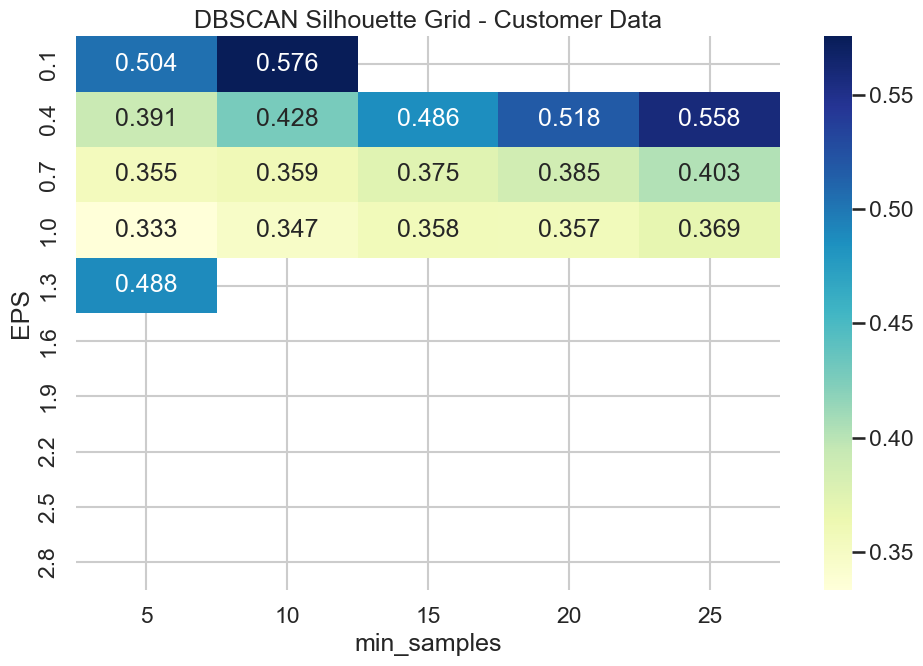

In [35]:
eps_values_cust = np.arange(0.1, 3.1, 0.3)
min_samp_cust = range(5, 26, 5)
sil_grid_cust = np.full((len(eps_values_cust), len(min_samp_cust)), np.nan)
noise_grid_cust = np.full((len(eps_values_cust), len(min_samp_cust)), np.nan)

for i, eps in enumerate(eps_values_cust):
    for j, ms in enumerate(min_samp_cust):
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_cust_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_grid_cust[i, j] = (labels == -1).sum() / len(labels) * 100
        mask = labels != -1
        if n_clusters > 1 and mask.sum() > n_clusters:
            sil_grid_cust[i, j] = silhouette_score(X_cust_scaled[mask], labels[mask])

plt.figure(figsize=(10, 7))
sil_df_cust = pd.DataFrame(sil_grid_cust,
                             index=[f'{e:.1f}' for e in eps_values_cust],
                             columns=[str(m) for m in min_samp_cust])
sns.heatmap(sil_df_cust, annot=True, fmt='.3f', cmap='YlGnBu')
plt.xlabel('min_samples')
plt.ylabel('EPS')
plt.title('DBSCAN Silhouette Grid - Customer Data')
plt.tight_layout()
plt.show()

In [36]:
# Reject configs where >50% noise, fallback to least-noisy valid config
NOISE_THRESHOLD = 50
sil_grid_cust_filtered = sil_grid_cust.copy()
sil_grid_cust_filtered[noise_grid_cust > NOISE_THRESHOLD] = np.nan

if not np.all(np.isnan(sil_grid_cust_filtered)):
    best_idx_cust = np.unravel_index(np.nanargmax(sil_grid_cust_filtered), sil_grid_cust_filtered.shape)
    best_eps_cust = eps_values_cust[best_idx_cust[0]]
    best_ms_cust = list(min_samp_cust)[best_idx_cust[1]]
    best_silhouette_dbscan_cust = sil_grid_cust_filtered[best_idx_cust]
elif not np.all(np.isnan(sil_grid_cust)):
    temp = noise_grid_cust.copy()
    temp[np.isnan(sil_grid_cust)] = 999
    best_idx_cust = np.unravel_index(np.argmin(temp), temp.shape)
    best_eps_cust = eps_values_cust[best_idx_cust[0]]
    best_ms_cust = list(min_samp_cust)[best_idx_cust[1]]
    best_silhouette_dbscan_cust = sil_grid_cust[best_idx_cust]
else:
    best_silhouette_dbscan_cust = float('nan')
    best_eps_cust = float('nan')
    best_ms_cust = 0
    n_clusters_db_cust = 0
    print("DBSCAN could not find any valid clusters for this data.")

if not np.isnan(best_silhouette_dbscan_cust):
    print(f"Best DBSCAN: EPS={best_eps_cust:.2f}, min_samples={best_ms_cust}, silhouette={best_silhouette_dbscan_cust:.4f}")

    db_cust_best = DBSCAN(eps=best_eps_cust, min_samples=best_ms_cust)
    labels_db_cust = db_cust_best.fit_predict(X_cust_scaled)
    n_clusters_db_cust = len(set(labels_db_cust)) - (1 if -1 in labels_db_cust else 0)
    n_noise_cust = (labels_db_cust == -1).sum()
    noise_pct_cust = n_noise_cust / len(X_cust_scaled) * 100
    print(f"DBSCAN found K={n_clusters_db_cust} clusters, {n_noise_cust} noise points ({noise_pct_cust:.1f}% of data)")

    if noise_pct_cust > 50:
        print(f"WARNING: {noise_pct_cust:.1f}% of points are noise. DBSCAN is not well-suited for Customer data.")

Best DBSCAN: EPS=1.30, min_samples=5, silhouette=0.4882
DBSCAN found K=2 clusters, 6 noise points (0.3% of data)


In [37]:
print("Comparison of Clustering Methods on Customer Data:")
print(f"  KMeans       K={best_k_cust_km}                     : Silhouette = {best_silhouette_kmeans_cust:.4f}")
print(f"  Hierarchical K={best_k_cust_hier} ({best_hier_cust['metric']}/{best_hier_cust['linkage']}): Silhouette = {best_silhouette_hier_cust:.4f}")
if not np.isnan(best_silhouette_dbscan_cust):
    print(f"  DBSCAN       K={n_clusters_db_cust} (eps={best_eps_cust:.1f}, ms={best_ms_cust})  : Silhouette = {best_silhouette_dbscan_cust:.4f}")
else:
    print(f"  DBSCAN       no valid clusters found")
print()
print("Note: Each method finds a different best K because they define clusters differently.")

Comparison of Clustering Methods on Customer Data:
  KMeans       K=4                     : Silhouette = 0.2414
  Hierarchical K=3 (euclidean/single): Silhouette = 0.3425
  DBSCAN       K=2 (eps=1.3, ms=5)  : Silhouette = 0.4882

Note: Each method finds a different best K because they define clusters differently.


**Conclusions - Customer Dataset:**
- Scaling is critical here due to the mix of binary features (Sex, Marital status) and continuous features (Income, Age).
- KMeans and Hierarchical Ward tend to perform best on this data after scaling.
- DBSCAN struggles with customer data because customer segments don't form density-separated groups — they overlap smoothly. When DBSCAN classifies most points as noise, its silhouette score and K value are unreliable.
- **Takeaway:** DBSCAN works best on data with clear density gaps between clusters. For customer segmentation with mixed features, KMeans or Hierarchical clustering are more appropriate.